In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

In [2]:
def to_month_start(s: pd.Series) -> pd.Series:
    dt = pd.to_datetime(s)
    # 월 시작일로 강제 변환 (버전 호환 안전)
    return pd.to_datetime(dt.dt.year.astype(str) + "-" +
                          dt.dt.month.astype(str) + "-01")

def pick_value_col(df: pd.DataFrame) -> str:
    # 가장 흔한 value 컬럼 우선
    for c in ["value", "Value", "val", "VAL", "data", "DATA"]:
        if c in df.columns:
            return c
    # 숫자형 첫 컬럼
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if len(num_cols) == 0:
        raise ValueError(f"Cannot find numeric value col. cols={df.columns.tolist()}")
    return num_cols[0]

def yoy(x: pd.Series) -> pd.Series:
    return x.pct_change(12)

def diff12(x: pd.Series) -> pd.Series:
    return x.diff(12)

def zscore(x: pd.Series) -> pd.Series:
    mu = x.mean(skipna=True)
    sd = x.std(skipna=True, ddof=0)
    if sd == 0 or np.isnan(sd):
        return x * np.nan
    return (x - mu) / sd

def mom_k(x: pd.Series, k: int) -> pd.Series:
    return x.pct_change(k)

def extract_periods(mask: np.ndarray, dates: pd.Series):
    """연속 True 구간을 (start_date, end_date) 리스트로 반환"""
    periods = []
    i = 0
    n = len(mask)
    while i < n:
        if mask[i]:
            s = i
            while i + 1 < n and mask[i + 1]:
                i += 1
            e = i
            periods.append((dates.iloc[s], dates.iloc[e]))
        i += 1
    return periods

In [3]:
BASE = "data"
pre = "data/preprocessed"
dec_path = os.path.join(BASE, "decoupling.csv")
assert os.path.exists(dec_path), f"missing: {dec_path}"

dec = pd.read_csv(dec_path)
dec["date"] = to_month_start(dec["date"])
dec = dec.sort_values("date").reset_index(drop=True)

# 전처리 파일들 로드
paths = sorted(glob.glob(os.path.join(pre, "전처리_*.csv")))
print("found preprocess files:", len(paths))
for p in paths[:5]:
    print(" -", os.path.basename(p))

series = {}
for p in paths:
    name = os.path.splitext(os.path.basename(p))[0].replace("전처리_", "")
    df = pd.read_csv(p)

    # date 컬럼 찾기
    if "date" not in df.columns:
        # 혹시 datetime 같은 이름이면 대응
        cand = [c for c in df.columns if c.lower() in ("date","datetime","time")]
        if not cand:
            raise ValueError(f"{p}: no date column. cols={df.columns.tolist()}")
        df = df.rename(columns={cand[0]:"date"})

    df["date"] = to_month_start(df["date"])
    vcol = pick_value_col(df)
    df = df[["date", vcol]].rename(columns={vcol: name})
    df = df.sort_values("date").reset_index(drop=True)

    series[name] = df

# 전처리 지표들 inner merge
macro = None
for name, df in series.items():
    macro = df.copy() if macro is None else macro.merge(df, on="date", how="inner")

# decoupling + macro merge (inner)
df = dec.merge(macro, on="date", how="inner").sort_values("date").reset_index(drop=True)

print("merged df shape:", df.shape)
print(df.columns.tolist())
df.head()

found preprocess files: 12
 - 전처리_M2.csv
 - 전처리_cpi.csv
 - 전처리_가계대출.csv
 - 전처리_기업대출.csv
 - 전처리_기준금리.csv
merged df shape: (71, 18)
['date', 'fin_index', 'real_index', 'gap', 'top_regime', 'bottom_regime', 'M2', 'cpi', '가계대출', '기업대출', '기준금리', '대출금리', '소매판매액지수', '신용스프레드', '신용카드사용액', '전산업생산지수', '코스피', '환율']


,date,fin_index,real_index,gap,top_regime,bottom_regime,M2,cpi,가계대출,기업대출,기준금리,대출금리,소매판매액지수,신용스프레드,신용카드사용액,전산업생산지수,코스피,환율
0,2008-01-01,-0.231403,1.242531,-1.473934,False,True,1105916.8,79.472,473606.9,465822.9,5.00,7.25,71.2,1.20,37047103,79.8,1624.68,943.85
1,2008-04-01,-0.324827,1.216186,-1.541013,False,True,1143956.6,80.962,485302.9,493407.0,5.00,6.91,72.3,0.93,37517521,79.9,1825.47,1003.00
2,2008-07-01,-1.038060,0.889147,-1.927208,False,True,1190474.9,82.747,498816.4,516928.7,5.00,7.12,69.8,1.03,40291279,79.2,1594.67,1012.25
3,2008-10-01,-3.450642,-0.855806,-2.594835,False,True,1237588.2,82.598,509177.8,528536.9,4.25,7.79,69.9,2.86,39319067,78.4,1113.06,1282.50
4,2009-01-01,-3.286671,-2.290712,-0.995959,False,False,1292462.7,82.450,511998.3,542479.1,2.50,5.91,69.1,3.90,35801266,73.7,1162.11,1381.50


In [4]:
cols = df.columns.tolist()

def find_col(keywords):
    for c in cols:
        lc = c.lower()
        if all(k in lc for k in keywords):
            return c
    return None

# 자동 매핑 (있으면 잡히고, 없으면 None)
MAP = {
    "M2": find_col(["m2"]),
    "BASE_RATE": find_col(["기준금리"]) or find_col(["base", "rate"]) or find_col(["policy", "rate"]),
    "SPREAD": find_col(["신용", "스프레드"]) or find_col(["spread"]),
    "FX": find_col(["환율"]) or find_col(["fx"]) or find_col(["exchange"]),
    "KOSPI": find_col(["코스피"]) or find_col(["kospi"]),
    "RETAIL": find_col(["소매"]) or find_col(["retail"]),
    "IP": find_col(["전산업", "생산"]) or find_col(["industrial", "production"]) or find_col(["ip"]),
    "CARD": find_col(["신용카드", "사용액"]) or find_col(["card"]),
}

MAP

{'M2': 'M2',
 'BASE_RATE': '기준금리',
 'SPREAD': '신용스프레드',
 'FX': '환율',
 'KOSPI': '코스피',
 'RETAIL': '소매판매액지수',
 'IP': '전산업생산지수',
 'CARD': '신용카드사용액'}

In [5]:
# 필요할 때만 수정
# 예:
# MAP["CARD"] = "신용카드사용액"
# MAP["SPREAD"] = "전처리_신용스프레드에서 들어온 실제 컬럼명"

missing = [k for k,v in MAP.items() if v is None]
print("missing keys:", missing)

# 존재하는 키만 사용하도록 체크
use_keys = [k for k,v in MAP.items() if v is not None]
print("using keys:", use_keys)

df[[ "date", "gap"] + [MAP[k] for k in use_keys]].head()

missing keys: []
using keys: ['M2', 'BASE_RATE', 'SPREAD', 'FX', 'KOSPI', 'RETAIL', 'IP', 'CARD']


,date,gap,M2,기준금리,신용스프레드,환율,코스피,소매판매액지수,전산업생산지수,신용카드사용액
0,2008-01-01,-1.473934,1105916.8,5.00,1.20,943.85,1624.68,71.2,79.8,37047103
1,2008-04-01,-1.541013,1143956.6,5.00,0.93,1003.00,1825.47,72.3,79.9,37517521
2,2008-07-01,-1.927208,1190474.9,5.00,1.03,1012.25,1594.67,69.8,79.2,40291279
3,2008-10-01,-2.594835,1237588.2,4.25,2.86,1282.50,1113.06,69.9,78.4,39319067
4,2009-01-01,-0.995959,1292462.7,2.50,3.90,1381.50,1162.11,69.1,73.7,35801266


In [6]:

feat = pd.DataFrame({"date": df["date"], "gap": df["gap"]})

def add_yoy_z(out, raw_col, out_name):
    x = df[raw_col].astype(float)
    out[out_name] = zscore(yoy(x))
    return out

def add_diff12_z(out, raw_col, out_name):
    x = df[raw_col].astype(float)
    out[out_name] = zscore(diff12(x))
    return out

# Build-up inputs (KOSPI 제외)
if MAP["M2"] is not None:       feat = add_yoy_z(feat, MAP["M2"], "m2_yoy_z")
if MAP["FX"] is not None:       feat = add_yoy_z(feat, MAP["FX"], "fx_yoy_z")
if MAP["RETAIL"] is not None:   feat = add_yoy_z(feat, MAP["RETAIL"], "retail_yoy_z")
if MAP["IP"] is not None:       feat = add_yoy_z(feat, MAP["IP"], "ip_yoy_z")
if MAP["CARD"] is not None:     feat = add_yoy_z(feat, MAP["CARD"], "card_yoy_z")

# rate/spread: 12m 변화량 z
if MAP["BASE_RATE"] is not None: feat = add_diff12_z(feat, MAP["BASE_RATE"], "base_rate_d12_z")
if MAP["SPREAD"] is not None:    feat = add_diff12_z(feat, MAP["SPREAD"], "spread_d12_z")

feat.tail(10)

,date,gap,m2_yoy_z,fx_yoy_z,retail_yoy_z,ip_yoy_z,card_yoy_z,base_rate_d12_z,spread_d12_z
61,2023-04-01,0.238701,0.735125,0.715913,0.046838,1.829136,2.879520,1.916184,-0.253089
62,2023-07-01,1.064299,0.348915,0.355043,-0.649848,1.254459,1.398788,2.093386,-0.714912
63,2023-10-01,0.921349,-0.082005,1.685446,-0.760367,1.263238,1.921660,2.093386,-0.615014
64,2024-01-01,-0.050548,-0.478561,1.724076,-1.266842,1.311398,2.416469,2.093386,-0.431595
65,2024-04-01,0.551985,-0.701878,2.247398,-1.998393,0.748327,0.796883,2.093386,-0.249814
66,2024-07-01,0.473888,-1.103694,1.677483,-2.273113,-0.066098,1.041014,2.093386,0.241487
67,2024-10-01,0.823816,-1.495464,1.450093,-2.397160,-0.122103,0.823665,1.738982,0.446195
68,2025-01-01,0.610511,-1.724539,1.908536,-2.126346,-1.387225,-0.221464,1.207376,0.398703
69,2025-04-01,0.427599,-1.971225,0.995825,-2.096470,-1.258451,-0.530890,0.852972,0.085908
70,2025-07-01,0.193536,-2.016904,0.333685,-1.473354,-1.372708,-0.378297,0.144164,-0.390653


In [7]:
# 실물 종합 z
real_parts = [c for c in ["retail_yoy_z","ip_yoy_z","card_yoy_z"] if c in feat.columns]
feat["real_z"] = feat[real_parts].mean(axis=1) if len(real_parts) > 0 else np.nan

# Build-up (KOSPI 제거)
terms = []
if "m2_yoy_z" in feat:          terms.append(feat["m2_yoy_z"])
if "fx_yoy_z" in feat:          terms.append(feat["fx_yoy_z"])
if "spread_d12_z" in feat:      terms.append(feat["spread_d12_z"])
if "base_rate_d12_z" in feat:   terms.append(-feat["base_rate_d12_z"])  # 완화 위험 가정

feat["build_up"] = np.nanmean(np.vstack([t.values for t in terms]), axis=0) - feat["real_z"]

# Trigger: KOSPI 모멘텀 제거, FX/Spread만 사용
if MAP["FX"] is not None:
    fx_m3 = mom_k(df[MAP["FX"]].astype(float), 3)
    feat["fx_mom3_z"] = zscore(fx_m3)

if MAP["SPREAD"] is not None:
    sp_m3 = df[MAP["SPREAD"]].astype(float).diff(3)
    feat["spread_mom3_z"] = zscore(sp_m3)

t_terms = []
if "fx_mom3_z" in feat:         t_terms.append(feat["fx_mom3_z"])
if "spread_mom3_z" in feat:     t_terms.append(feat["spread_mom3_z"])
feat["trigger"] = np.nanmean(np.vstack([t.values for t in t_terms]), axis=0) if len(t_terms) else np.nan

feat["ews_total"] = 0.6 * feat["build_up"] + 0.4 * feat["trigger"]

feat[["date","gap","real_z","build_up","trigger","ews_total"]].tail(12)

C:\Users\may670\AppData\Local\Temp\ipykernel_8396\2679949088.py:12: RuntimeWarning: Mean of empty slice
  feat["build_up"] = np.nanmean(np.vstack([t.values for t in terms]), axis=0) - feat["real_z"]
C:\Users\may670\AppData\Local\Temp\ipykernel_8396\2679949088.py:26: RuntimeWarning: Mean of empty slice
  feat["trigger"] = np.nanmean(np.vstack([t.values for t in t_terms]), axis=0) if len(t_terms) else np.nan


,date,gap,real_z,build_up,trigger,ews_total
59,2022-10-01,-1.698065,0.289304,0.732883,1.405978,1.002121
60,2023-01-01,0.255413,-0.464756,0.815723,0.200414,0.569600
61,2023-04-01,0.238701,1.585165,-1.764723,-0.007567,-1.061861
62,2023-07-01,1.064299,0.667800,-1.193884,-0.978876,-1.107881
63,2023-10-01,0.921349,0.808177,-1.084417,0.094814,-0.612725
64,2024-01-01,-0.050548,0.820342,-1.140208,-0.159895,-0.748083
65,2024-04-01,0.551985,-0.151061,-0.048359,0.168464,0.038370
66,2024-07-01,0.473888,-0.432732,0.113205,-0.284493,-0.045874
67,2024-10-01,0.823816,-0.565200,0.230660,-0.065067,0.112370
68,2025-01-01,0.610511,-1.245012,1.088843,0.287251,0.768206


In [8]:
H = 3
Q = 0.9

thr_gap = feat["gap"].quantile(Q)

# 디커플링 상태(구간)
feat["is_dec"] = (feat["gap"] >= thr_gap).astype(int)

# "진입 이벤트": 이번 달 1이고 지난 달 0인 순간
feat["dec_enter"] = ((feat["is_dec"] == 1) & (feat["is_dec"].shift(1).fillna(0) == 0)).astype(int)

# (옵션) "이탈 이벤트"도 참고용
feat["dec_exit"] = ((feat["is_dec"] == 0) & (feat["is_dec"].shift(1).fillna(0) == 1)).astype(int)

# label 1) 앞으로 H개월 안에 진입 이벤트가 한 번이라도 있으면 1
y_in = np.zeros(len(feat), dtype=int)
enter = feat["dec_enter"].values
for i in range(len(feat)):
    j2 = min(len(feat), i + H + 1)
    y_in[i] = 1 if enter[i+1:j2].any() else 0
feat[f"y_enter_in_{H}m"] = y_in

# label 2) 정확히 H개월 뒤 진입 이벤트가 있으면 1 (더 어려움/더 깔끔)
feat[f"y_enter_at_{H}m"] = feat["dec_enter"].shift(-H).fillna(0).astype(int)

print("thr_gap =", float(thr_gap))
feat[["date","gap","is_dec","dec_enter","dec_exit", f"y_enter_in_{H}m", f"y_enter_at_{H}m"]].tail(20)

thr_gap = 0.9235355197966736


,date,gap,is_dec,dec_enter,dec_exit,y_enter_in_3m,y_enter_at_3m
51,2020-10-01,0.836037,0,0,0,1,0
52,2021-01-01,1.743078,1,1,0,0,0
53,2021-04-01,-0.576679,0,0,1,0,0
54,2021-07-01,0.162248,0,0,0,0,0
55,2021-10-01,-0.418818,0,0,0,0,0
56,2022-01-01,-1.691061,0,0,0,0,0
57,2022-04-01,-1.248759,0,0,0,0,0
58,2022-07-01,-1.648731,0,0,0,0,0
59,2022-10-01,-1.698065,0,0,0,1,1
60,2023-01-01,0.255413,0,0,0,1,0


In [9]:
# --- evaluation cell (label만 선택해서 비교) ---

y_col = f"y_enter_in_{H}m"   # 추천: 먼저 이걸로
# y_col = f"y_enter_at_{H}m" # 더 타이트하게 보려면 이걸로

eval_df = feat.dropna(subset=["ews_total", y_col]).copy()

y_true = eval_df[y_col].values
y_score = eval_df["ews_total"].values

print("N =", len(eval_df), "| positives =", int(y_true.sum()), "| pos_rate =", y_true.mean())

roc = roc_auc_score(y_true, y_score)
ap  = average_precision_score(y_true, y_score)

print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC : {ap:.4f}")

# threshold sweep: score 상위 q를 알람으로 간주
qs = np.linspace(0.70, 0.95, 26)
rows = []
best = None

for q in qs:
    thr = np.quantile(y_score, q)
    y_pred = (y_score >= thr).astype(int)

    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    rows.append((q, thr, p, r, f1, y_pred.mean()))
    if best is None or f1 > best[4]:
        best = (q, thr, p, r, f1, y_pred.mean())

res = pd.DataFrame(rows, columns=["q","thr","precision","recall","f1","alarm_rate"])
display(res.tail(10))
print("\nBEST by F1:", best)

# confusion matrix at best threshold
best_thr = best[1]
y_best = (y_score >= best_thr).astype(int)
cm = confusion_matrix(y_true, y_best)
print("\nConfusion Matrix [[TN FP],[FN TP]]:\n", cm)

N = 59 | positives = 18 | pos_rate = 0.3050847457627119
ROC-AUC: 0.5650
PR-AUC : 0.4732


,q,thr,precision,recall,f1,alarm_rate
16,0.86,0.666110,0.444444,0.222222,0.296296,0.152542
17,0.87,0.676523,0.500000,0.222222,0.307692,0.135593
18,0.88,0.681842,0.571429,0.222222,0.320000,0.118644
19,0.89,0.719847,0.571429,0.222222,0.320000,0.118644
20,0.90,0.749438,0.500000,0.166667,0.250000,0.101695
21,0.91,0.763045,0.500000,0.166667,0.250000,0.101695
22,0.92,0.780899,0.600000,0.166667,0.260870,0.084746
23,0.93,0.801350,0.600000,0.166667,0.260870,0.084746
24,0.94,0.816265,0.750000,0.166667,0.272727,0.067797
25,0.95,0.845484,1.000000,0.166667,0.285714,0.050847



BEST by F1: (np.float64(0.82), np.float64(0.5412698408221527), 0.45454545454545453, 0.2777777777777778, 0.3448275862068966, np.float64(0.1864406779661017))

Confusion Matrix [[TN FP],[FN TP]]:
 [[35  6]
 [13  5]]


In [10]:
# --- lead time diagnostics: alarm이 진입 이벤트보다 얼마나 앞서나 ---

# 알람을 score 상위 q로 단순화(히스테리시스 말고, 선행성 확인용)
alarm_q = 0.9
thr_alarm = np.quantile(eval_df["ews_total"].values, alarm_q)
alarm = (eval_df["ews_total"].values >= thr_alarm)

enter_ev = eval_df["dec_enter"].values.astype(bool)
dates = eval_df["date"].reset_index(drop=True)

enter_idx = np.where(enter_ev)[0]
alarm_idx = np.where(alarm)[0]

leads = []
for ei in enter_idx:
    # 진입 이전(<=ei) 중 가장 가까운 알람 찾기
    prev_alarms = alarm_idx[alarm_idx <= ei]
    if len(prev_alarms) == 0:
        leads.append(np.nan)
    else:
        leads.append(ei - prev_alarms[-1])

lead_series = pd.Series(leads)
print("Enter events:", len(enter_idx))
print("Lead (months) summary:")
print(lead_series.describe())

# 보기 좋게 출력
rows = []
for k, ei in enumerate(enter_idx):
    la = leads[k]
    rows.append({
        "enter_date": dates.iloc[ei],
        "lead_months": la,
        "prev_alarm_date": (dates.iloc[ei-int(la)] if pd.notna(la) else pd.NaT)
    })
pd.DataFrame(rows)

Enter events: 6
Lead (months) summary:
count    4.000000
mean     2.500000
std      3.316625
min      0.000000
25%      0.000000
50%      1.500000
75%      4.000000
max      7.000000
dtype: float64


,enter_date,lead_months,prev_alarm_date
0,2013-01-01,NaN,NaT
1,2015-01-01,NaN,NaT
2,2017-10-01,7.0,2016-01-01
3,2020-04-01,0.0,2020-04-01
4,2021-01-01,0.0,2021-01-01
5,2023-07-01,3.0,2022-10-01


In [11]:
enter_q = 0.90
exit_q  = 0.70
min_on  = 2
min_off = 2

s = eval_df["ews_total"].values
dates = eval_df["date"].reset_index(drop=True)
thr_enter = np.quantile(s, enter_q)
thr_exit  = np.quantile(s, exit_q)

alarm = np.zeros(len(s), dtype=bool)
state = False
on_cnt = 0
off_cnt = 0

for i in range(len(s)):
    if not state:
        # enter 조건 충족을 min_on개월 연속 확인
        if s[i] >= thr_enter:
            on_cnt += 1
        else:
            on_cnt = 0
        if on_cnt >= min_on:
            state = True
            alarm[i] = True
            off_cnt = 0
    else:
        alarm[i] = True
        # exit 조건 충족을 min_off개월 연속 확인
        if s[i] <= thr_exit:
            off_cnt += 1
        else:
            off_cnt = 0
        if off_cnt >= min_off:
            state = False
            on_cnt = 0

periods = extract_periods(alarm, dates)
print("alarm periods:")
for a,b in periods:
    print(" -", a.date(), "~", b.date())

alarm_df = pd.DataFrame({"start":[a for a,_ in periods], "end":[b for _,b in periods]})
alarm_df

alarm periods:
 - 2020-07-01 ~ 2023-07-01


,start,end
0,2020-07-01,2023-07-01


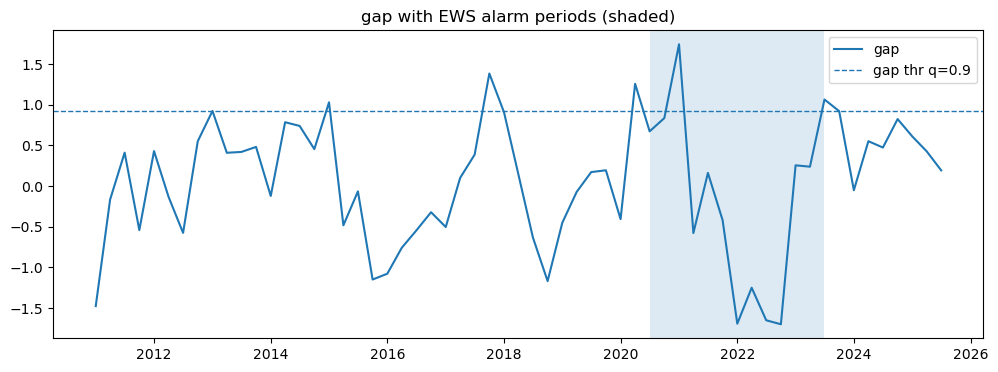

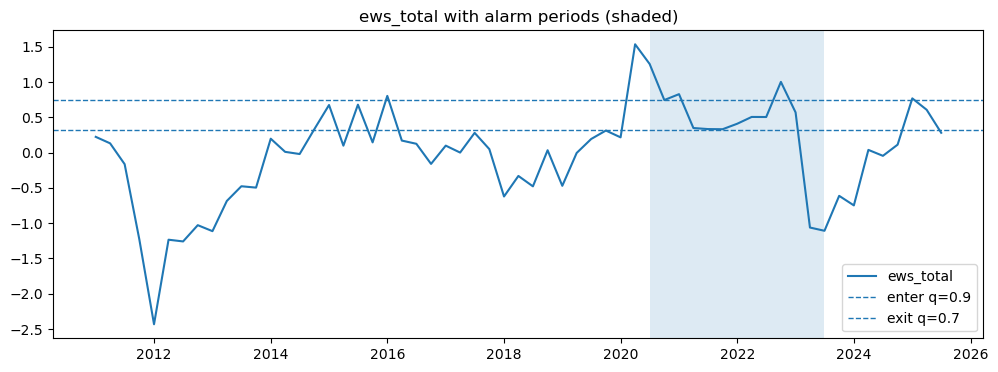

In [12]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(eval_df["date"], eval_df["gap"], label="gap")
ax.axhline(thr_gap, linestyle="--", linewidth=1, label=f"gap thr q={Q}")

for (a,b) in periods:
    ax.axvspan(a, b, alpha=0.15)

ax.set_title("gap with EWS alarm periods (shaded)")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(eval_df["date"], eval_df["ews_total"], label="ews_total")
ax.axhline(thr_enter, linestyle="--", linewidth=1, label=f"enter q={enter_q}")
ax.axhline(thr_exit, linestyle="--", linewidth=1, label=f"exit q={exit_q}")

for (a,b) in periods:
    ax.axvspan(a, b, alpha=0.15)

ax.set_title("ews_total with alarm periods (shaded)")
ax.legend()
plt.show()

In [ ]:
# out1 = os.path.join(BASE, "ews_dataset.csv")
# out2 = os.path.join(BASE, "ews_alarm_periods.csv")

# feat.to_csv(out1, index=False)
# alarm_df.to_csv(out2, index=False)

# print("saved:", out1)
# print("saved:", out2)

# 변화율로 보기

In [13]:
# --- 변화율(가속) 기반 EWS 점수 생성 ---
# 기존 feat (m2_yoy_z, fx_yoy_z, spread_d12_z, base_rate_d12_z, real_z, fx_mom3_z, spread_mom3_z)가 있다고 가정

feat_v = feat.copy()

# 1차 변화(월간 변화): "추세의 기울기"
for c in ["m2_yoy_z", "fx_yoy_z", "spread_d12_z", "base_rate_d12_z", "real_z"]:
    if c in feat_v.columns:
        feat_v[f"d1_{c}"] = feat_v[c].diff(1)

# 2차 변화(가속): "기울기의 변화" (전환점 탐지에 유리)
for c in ["m2_yoy_z", "fx_yoy_z", "spread_d12_z", "base_rate_d12_z", "real_z"]:
    if c in feat_v.columns:
        feat_v[f"d2_{c}"] = feat_v[c].diff(1).diff(1)

# ---- Build-up (change-based) ----
# 디커플링 직전: 유동성 가속(+), 스프레드 가속(+), 환율 가속(+), 실물 둔화 가속( -real 의 가속은 +로 넣는 느낌)
b_terms = []

# 2차 변화 위주 (전환 포착)
if "d2_m2_yoy_z" in feat_v:        b_terms.append(feat_v["d2_m2_yoy_z"])
if "d2_spread_d12_z" in feat_v:    b_terms.append(feat_v["d2_spread_d12_z"])
if "d2_fx_yoy_z" in feat_v:        b_terms.append(feat_v["d2_fx_yoy_z"])
if "d2_real_z" in feat_v:          b_terms.append(-feat_v["d2_real_z"])   # 실물 둔화(실물z 하락 가속) => -d2_real을 +
# 금리: 완화 가속(금리 d12가 더 내려가는 방향)이 위험이라는 가정
if "d2_base_rate_d12_z" in feat_v: b_terms.append(-feat_v["d2_base_rate_d12_z"])

feat_v["build_up_v"] = np.nanmean(np.vstack([t.values for t in b_terms]), axis=0)

# ---- Trigger (change-based) ----
# 급변 신호는 1차 변화 + 기존 mom3 같이 섞어도 됨
t_terms = []
if "d1_spread_d12_z" in feat_v:     t_terms.append(feat_v["d1_spread_d12_z"])
if "d1_fx_yoy_z" in feat_v:         t_terms.append(feat_v["d1_fx_yoy_z"])
if "spread_mom3_z" in feat_v:       t_terms.append(feat_v["spread_mom3_z"])
if "fx_mom3_z" in feat_v:           t_terms.append(feat_v["fx_mom3_z"])

feat_v["trigger_v"] = np.nanmean(np.vstack([t.values for t in t_terms]), axis=0) if len(t_terms) else np.nan

# Total (가중치는 일단 동일)
feat_v["ews_total_v"] = 0.6 * feat_v["build_up_v"] + 0.4 * feat_v["trigger_v"]

feat_v[["date","gap","build_up_v","trigger_v","ews_total_v"]].tail(12)

C:\Users\may670\AppData\Local\Temp\ipykernel_8396\218389691.py:28: RuntimeWarning: Mean of empty slice
  feat_v["build_up_v"] = np.nanmean(np.vstack([t.values for t in b_terms]), axis=0)
C:\Users\may670\AppData\Local\Temp\ipykernel_8396\218389691.py:38: RuntimeWarning: Mean of empty slice
  feat_v["trigger_v"] = np.nanmean(np.vstack([t.values for t in t_terms]), axis=0) if len(t_terms) else np.nan


,date,gap,build_up_v,trigger_v,ews_total_v
59,2022-10-01,-1.698065,0.306343,1.171390,0.652362
60,2023-01-01,0.255413,-0.631825,-0.437134,-0.553949
61,2023-04-01,0.238701,-0.448241,-0.204802,-0.350865
62,2023-07-01,1.064299,0.740657,-0.695111,0.166350
63,2023-10-01,0.921349,0.265548,0.404982,0.321322
64,2024-01-01,-0.050548,-0.209135,-0.024435,-0.135255
65,2024-04-01,0.551985,0.327972,0.260508,0.300986
66,2024-07-01,0.473888,-0.330390,-0.161900,-0.262994
67,2024-10-01,0.823816,0.054236,-0.038203,0.017260
68,2025-01-01,0.610511,0.264174,0.246363,0.257050


In [14]:
# --- 평가: 변화율 점수 ews_total_v ---
# label은 기존과 동일하게 사용

y_col = f"y_enter_in_{H}m"   # 또는 f"y_enter_at_{H}m"
score_col = "ews_total_v"

eval_df = feat_v.dropna(subset=[score_col, y_col]).copy()

y_true = eval_df[y_col].values
y_score = eval_df[score_col].values

print("N =", len(eval_df), "| positives =", int(y_true.sum()), "| pos_rate =", y_true.mean())

roc = roc_auc_score(y_true, y_score)
ap  = average_precision_score(y_true, y_score)
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC : {ap:.4f}")

# threshold sweep
qs = np.linspace(0.70, 0.95, 26)
rows, best = [], None

for q in qs:
    thr = np.quantile(y_score, q)
    y_pred = (y_score >= thr).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    rows.append((q, thr, p, r, f1, y_pred.mean()))
    if best is None or f1 > best[4]:
        best = (q, thr, p, r, f1, y_pred.mean())

res = pd.DataFrame(rows, columns=["q","thr","precision","recall","f1","alarm_rate"])
display(res.tail(10))
print("\nBEST by F1:", best)

best_thr = best[1]
y_best = (y_score >= best_thr).astype(int)
cm = confusion_matrix(y_true, y_best)
print("\nConfusion Matrix [[TN FP],[FN TP]]:\n", cm)

# --- 선행성(lead months) ---
alarm_q = 0.90
thr_alarm = np.quantile(y_score, alarm_q)
alarm = (y_score >= thr_alarm)

enter_ev = eval_df["dec_enter"].values.astype(bool)
dates = eval_df["date"].reset_index(drop=True)

enter_idx = np.where(enter_ev)[0]
alarm_idx = np.where(alarm)[0]

leads = []
for ei in enter_idx:
    prev_alarms = alarm_idx[alarm_idx <= ei]
    leads.append(np.nan if len(prev_alarms)==0 else ei - prev_alarms[-1])

lead_series = pd.Series(leads)
print("\nEnter events:", len(enter_idx))
print("Lead (months) summary:")
print(lead_series.describe())

rows = []
for k, ei in enumerate(enter_idx):
    la = leads[k]
    rows.append({
        "enter_date": dates.iloc[ei],
        "lead_months": la,
        "prev_alarm_date": (dates.iloc[ei-int(la)] if pd.notna(la) else pd.NaT)
    })
pd.DataFrame(rows)

N = 57 | positives = 18 | pos_rate = 0.3157894736842105
ROC-AUC: 0.4687
PR-AUC : 0.4147


,q,thr,precision,recall,f1,alarm_rate
16,0.86,0.264080,0.375000,0.166667,0.230769,0.140351
17,0.87,0.288684,0.375000,0.166667,0.230769,0.140351
18,0.88,0.306680,0.428571,0.166667,0.240000,0.122807
19,0.89,0.318068,0.428571,0.166667,0.240000,0.122807
20,0.90,0.373381,0.500000,0.166667,0.250000,0.105263
21,0.91,0.446264,0.500000,0.166667,0.250000,0.105263
22,0.92,0.474860,0.600000,0.166667,0.260870,0.087719
23,0.93,0.496824,0.750000,0.166667,0.272727,0.070175
24,0.94,0.499438,0.750000,0.166667,0.272727,0.070175
25,0.95,0.521971,1.000000,0.166667,0.285714,0.052632



BEST by F1: (np.float64(0.95), np.float64(0.5219707152361959), 1.0, 0.16666666666666666, 0.2857142857142857, np.float64(0.05263157894736842))

Confusion Matrix [[TN FP],[FN TP]]:
 [[39  0]
 [15  3]]

Enter events: 6
Lead (months) summary:
count     6.000000
mean      4.500000
std       3.885872
min       0.000000
25%       3.000000
50%       3.000000
75%       6.000000
max      11.000000
dtype: float64


,enter_date,lead_months,prev_alarm_date
0,2013-01-01,3,2012-04-01
1,2015-01-01,11,2012-04-01
2,2017-10-01,7,2016-01-01
3,2020-04-01,0,2020-04-01
4,2021-01-01,3,2020-04-01
5,2023-07-01,3,2022-10-01


# 점수 구조를 바꿔보자. 혼합 점수로

In [15]:
# --- MIXED EWS SCORE ---
# feat: 레벨 기반 ews_total
# feat_v: 변화율 기반 ews_total_v

feat_mix = feat_v.copy()

# 두 점수 정규화 (스케일 맞추기 위해 zscore 다시)
feat_mix["ews_level_z"] = zscore(feat["ews_total"])
feat_mix["ews_change_z"] = zscore(feat_v["ews_total_v"])

# 혼합 가중치 (처음엔 0.5/0.5)
w_level = 0.5
w_change = 0.5

feat_mix["ews_mix"] = w_level * feat_mix["ews_level_z"] + \
                      w_change * feat_mix["ews_change_z"]

feat_mix[["date","gap","ews_level_z","ews_change_z","ews_mix"]].tail(12)

,date,gap,ews_level_z,ews_change_z,ews_mix
59,2022-10-01,-1.698065,1.455792,1.799773,1.627783
60,2023-01-01,0.255413,0.836268,-1.505337,-0.334535
61,2023-04-01,0.238701,-1.500562,-0.948919,-1.224741
62,2023-07-01,1.064299,-1.566480,0.468173,-0.549153
63,2023-10-01,0.921349,-0.857240,0.892773,0.017767
64,2024-01-01,-0.050548,-1.051121,-0.358179,-0.704650
65,2024-04-01,0.551985,0.075359,0.837057,0.456208
66,2024-07-01,0.473888,-0.045309,-0.708164,-0.376737
67,2024-10-01,0.823816,0.181352,0.059690,0.120521
68,2025-01-01,0.610511,1.120743,0.716678,0.918710


In [16]:
# --- 평가: 혼합 점수 ---

y_col = f"y_enter_in_{H}m"  # 그대로 사용
score_col = "ews_mix"

eval_df = feat_mix.dropna(subset=[score_col, y_col]).copy()

y_true = eval_df[y_col].values
y_score = eval_df[score_col].values

print("N =", len(eval_df), "| positives =", int(y_true.sum()), "| pos_rate =", y_true.mean())

roc = roc_auc_score(y_true, y_score)
ap  = average_precision_score(y_true, y_score)
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC : {ap:.4f}")

# threshold sweep
qs = np.linspace(0.70, 0.95, 26)
rows, best = [], None

for q in qs:
    thr = np.quantile(y_score, q)
    y_pred = (y_score >= thr).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    rows.append((q, thr, p, r, f1, y_pred.mean()))
    if best is None or f1 > best[4]:
        best = (q, thr, p, r, f1, y_pred.mean())

res = pd.DataFrame(rows, columns=["q","thr","precision","recall","f1","alarm_rate"])
display(res.tail(10))
print("\nBEST by F1:", best)

best_thr = best[1]
y_best = (y_score >= best_thr).astype(int)
cm = confusion_matrix(y_true, y_best)
print("\nConfusion Matrix [[TN FP],[FN TP]]:\n", cm)

N = 57 | positives = 18 | pos_rate = 0.3157894736842105
ROC-AUC: 0.5698
PR-AUC : 0.4679


,q,thr,precision,recall,f1,alarm_rate
16,0.86,0.640914,0.375000,0.166667,0.230769,0.140351
17,0.87,0.675550,0.375000,0.166667,0.230769,0.140351
18,0.88,0.717053,0.428571,0.166667,0.240000,0.122807
19,0.89,0.765424,0.428571,0.166667,0.240000,0.122807
20,0.90,0.835030,0.500000,0.166667,0.250000,0.105263
21,0.91,0.913132,0.500000,0.166667,0.250000,0.105263
22,0.92,1.024068,0.600000,0.166667,0.260870,0.087719
23,0.93,1.133882,0.750000,0.166667,0.272727,0.070175
24,0.94,1.221799,0.750000,0.166667,0.272727,0.070175
25,0.95,1.294647,1.000000,0.166667,0.285714,0.052632



BEST by F1: (np.float64(0.7), np.float64(0.3015683976777137), 0.29411764705882354, 0.2777777777777778, 0.2857142857142857, np.float64(0.2982456140350877))

Confusion Matrix [[TN FP],[FN TP]]:
 [[27 12]
 [13  5]]


In [17]:
# --- Lead months (혼합 점수) ---

alarm_q = 0.90
thr_alarm = np.quantile(y_score, alarm_q)
alarm = (y_score >= thr_alarm)

enter_ev = eval_df["dec_enter"].values.astype(bool)
dates = eval_df["date"].reset_index(drop=True)

enter_idx = np.where(enter_ev)[0]
alarm_idx = np.where(alarm)[0]

leads = []
for ei in enter_idx:
    prev_alarms = alarm_idx[alarm_idx <= ei]
    leads.append(np.nan if len(prev_alarms)==0 else ei - prev_alarms[-1])

lead_series = pd.Series(leads)
print("Enter events:", len(enter_idx))
print("Lead (months) summary:")
print(lead_series.describe())

rows = []
for k, ei in enumerate(enter_idx):
    la = leads[k]
    rows.append({
        "enter_date": dates.iloc[ei],
        "lead_months": la,
        "prev_alarm_date": (dates.iloc[ei-int(la)] if pd.notna(la) else pd.NaT)
    })
pd.DataFrame(rows)

Enter events: 6
Lead (months) summary:
count     6.000000
mean      4.500000
std       3.885872
min       0.000000
25%       3.000000
50%       3.000000
75%       6.000000
max      11.000000
dtype: float64


,enter_date,lead_months,prev_alarm_date
0,2013-01-01,3,2012-04-01
1,2015-01-01,11,2012-04-01
2,2017-10-01,7,2016-01-01
3,2020-04-01,0,2020-04-01
4,2021-01-01,3,2020-04-01
5,2023-07-01,3,2022-10-01
